# Netflix Content Analysis — Exploratory Data Analysis

## Overview
This project analyzes Netflix's content library using Python to uncover trends 
in content type, country of origin, genres, ratings and growth over time.

## Dataset
- Source: Netflix Movies and TV Shows (Kaggle)
- Size: 8000+ titles
- Columns: type, title, director, cast, country, date_added, release_year, 
  rating, duration, listed_in

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#df = pd.read_csv('netflix_titles.csv', on_bad_lines='skip')
#df = pd.read_csv('netflix_titles.csv', lineterminator='\n')
df = pd.read_csv('netflix_titles.csv', engine='python', on_bad_lines='skip')

In [26]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [27]:
df.shape


(2656, 12)

In [28]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [29]:
df.info

<bound method DataFrame.info of      show_id     type                     title          director  \
0         s1    Movie      Dick Johnson Is Dead   Kirsten Johnson   
1         s2  TV Show             Blood & Water               NaN   
2         s3  TV Show                 Ganglands   Julien Leclercq   
3         s4  TV Show     Jailbirds New Orleans               NaN   
4         s5  TV Show              Kota Factory               NaN   
...      ...      ...                       ...               ...   
2651   s2652  TV Show             Absurd Planet               NaN   
2652   s2653    Movie           Circus of Books      Rachel Mason   
2653   s2654    Movie    The Plagues of Breslau       Patryk Vega   
2654   s2655    Movie                The Set Up  Niyi Akinmolayan   
2655   s2656    Movie  The Silence of the Marsh        Marc Vigil   

                                                   cast        country  \
0                                                   NaN  United S

In [30]:
df.isnull().sum()

show_id           0
type              0
title             0
director        861
cast            260
country         432
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

In [31]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [32]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Movies vs TV Shows

Netflix's content library is dominated by Movies compared to TV Shows. 
This suggests Netflix has historically focused more on film licensing and production.

C:\Users\Asus\AppData\Local\Temp\ipykernel_13836\2561988645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


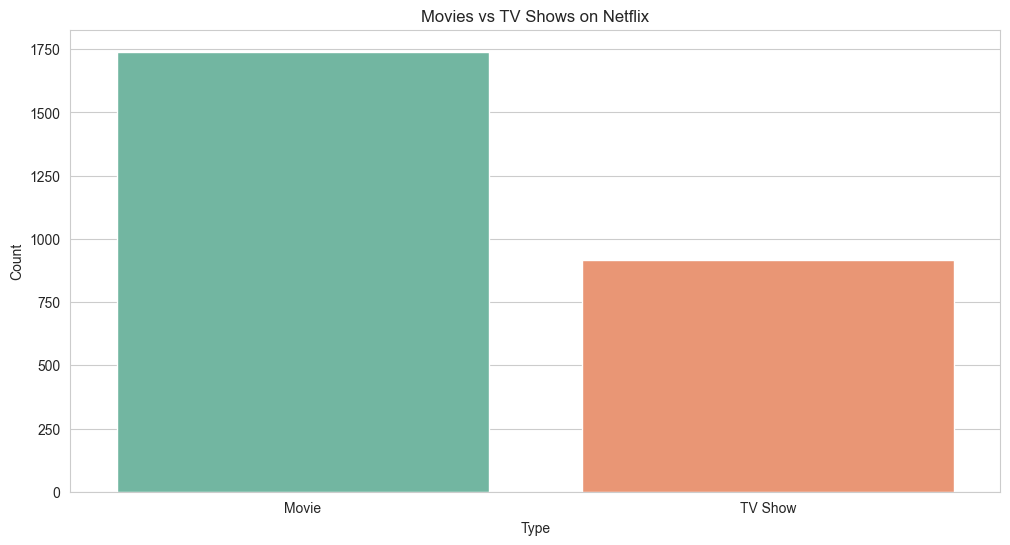

In [36]:
content_type = df['type'].value_counts()

plt.figure()
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

## 2. Content Added Over the Years

Analyzing how Netflix's content library has grown year by year.

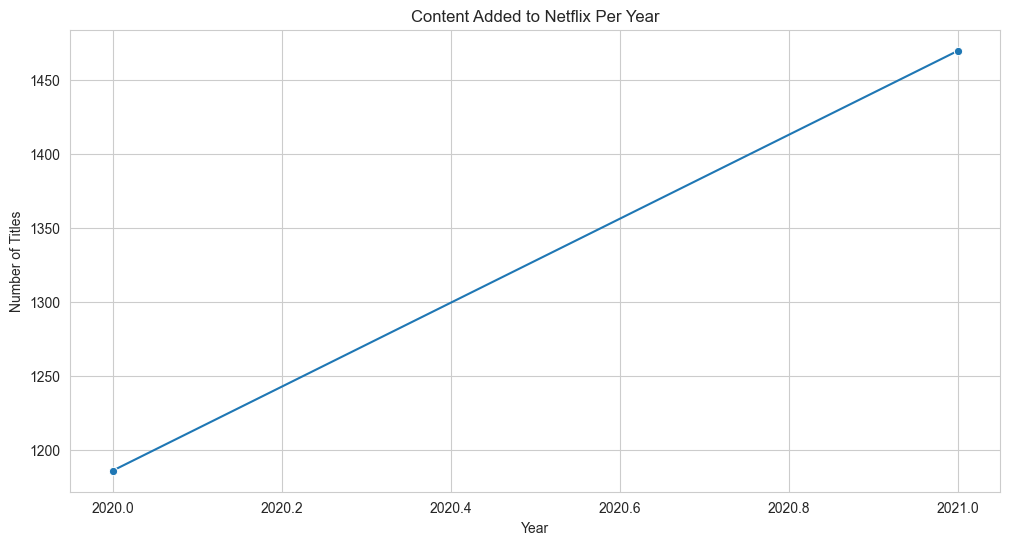

In [37]:
plt.figure()
yearly_content = df['year_added'].value_counts().sort_index()
sns.lineplot(x=yearly_content.index, y=yearly_content.values, marker='o')
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

## 3. Top 10 Countries Producing Netflix Content

Which countries contribute the most content to Netflix?

C:\Users\Asus\AppData\Local\Temp\ipykernel_13836\4061564485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


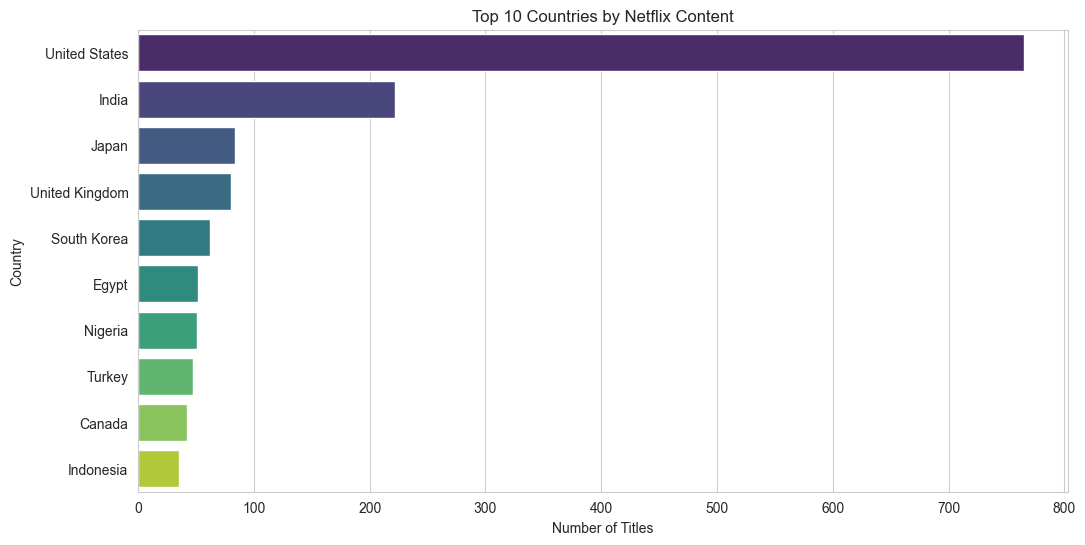

In [38]:
top_countries = df['country'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

## 4. Content Ratings Distribution

What are the most common content ratings on Netflix?

C:\Users\Asus\AppData\Local\Temp\ipykernel_13836\2589470072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='coolwarm')


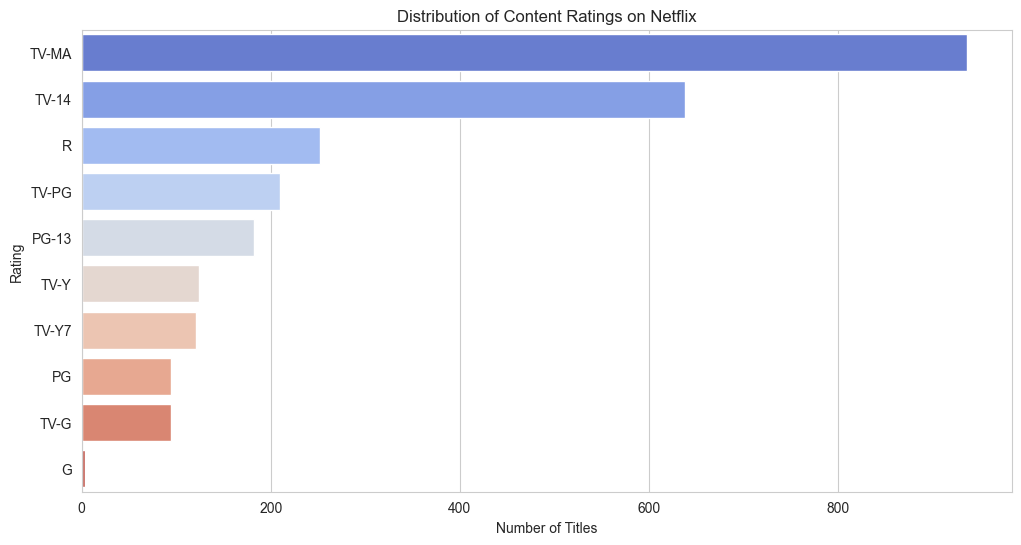

In [39]:
plt.figure()
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='coolwarm')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()

## 5. Top 10 Genres on Netflix

What genres does Netflix have the most content in?

C:\Users\Asus\AppData\Local\Temp\ipykernel_13836\489741162.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')


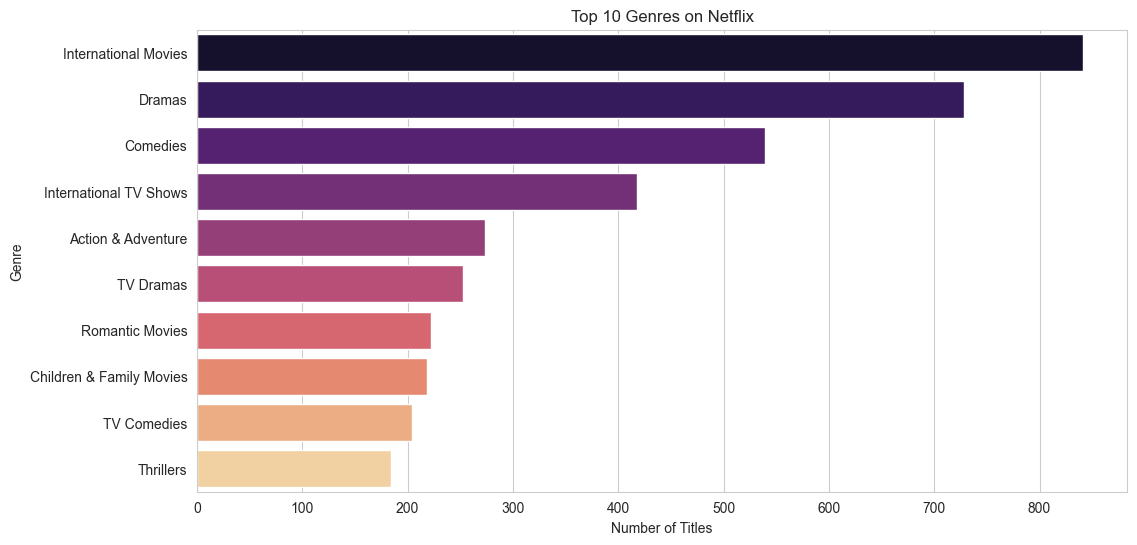

In [40]:
from collections import Counter

genres = df['listed_in'].dropna().str.split(', ')
genre_list = [genre for sublist in genres for genre in sublist]
genre_counts = Counter(genre_list)
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure()
sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

## 6. Movies vs TV Shows Added Over the Years

How has the split between Movies and TV Shows changed over time?

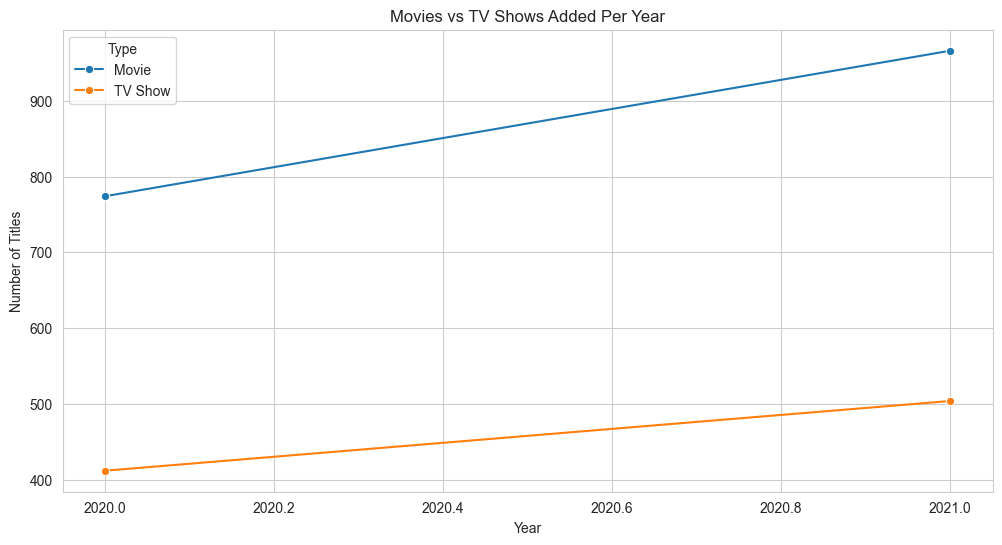

In [41]:
plt.figure()
yearly_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')
sns.lineplot(data=yearly_type, x='year_added', y='count', hue='type', marker='o')
plt.title('Movies vs TV Shows Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.show()

## Key Findings

1. Netflix has significantly more Movies than TV Shows (roughly 70/30 split)
2. Content additions grew explosively between 2015 and 2019
3. United States leads content production, followed by India and Japan
4. Netflix primarily targets mature audiences — TV-MA is the most common rating
5. International Movies, Dramas and Comedies are the top 3 genres
6. Movies continue to dominate over TV Shows with a widening gap over time